In [1]:
!pip install numpy pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Numerical columns: 6
Categorical columns: 7


In [4]:
!pip uninstall sklearn
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
from sklearn.impute import SimpleImputer
# Impute Missing Values
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
# Applying values 
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Check for remaining missing values
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
# Output first few rows
print(df.head())


        price    area  bedrooms  bathrooms  stories mainroad guestroom  \
0  13300000.0  7420.0       4.0        2.0      3.0      yes        no   
1  12250000.0  8960.0       4.0        4.0      4.0      yes        no   
2  12250000.0  9960.0       3.0        2.0      2.0      yes        no   
3  12215000.0  7500.0       4.0        2.0      2.0      yes        no   
4  11410000.0  7420.0       4.0        1.0      2.0      yes       yes   

  basement hotwaterheating airconditioning  parking prefarea furnishingstatus  
0       no              no             yes      2.0      yes        furnished  
1       no              no             yes      3.0       no        furnished  
2      yes              no              no      2.0      yes   semi-furnished  
3      yes              no             yes      3.0      yes        furnished  
4      yes              no             yes      2.0       no        furnished  


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

# Create the ColumnTransformer with OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'  # Keep other columns unchanged
)

df_encoded_array = preprocessor.fit_transform(df)

# Get feature names after encoding
ohe = preprocessor.named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(cat_cols)

# Combine encoded categorical columns with other columns
import numpy as np

other_cols = [col for col in df.columns if col not in cat_cols]
all_cols = list(encoded_cat_cols) + other_cols

df_encoded = pd.DataFrame(df_encoded_array, columns=all_cols)

print(df_encoded.head())


   mainroad_yes  guestroom_yes  basement_yes  hotwaterheating_yes  \
0           1.0            0.0           0.0                  0.0   
1           1.0            0.0           0.0                  0.0   
2           1.0            0.0           1.0                  0.0   
3           1.0            0.0           1.0                  0.0   
4           1.0            1.0           1.0                  0.0   

   airconditioning_yes  prefarea_yes  furnishingstatus_semi-furnished  \
0                  1.0           1.0                              0.0   
1                  1.0           0.0                              0.0   
2                  0.0           1.0                              1.0   
3                  1.0           1.0                              0.0   
4                  1.0           0.0                              0.0   

   furnishingstatus_unfurnished       price    area  bedrooms  bathrooms  \
0                           0.0  13300000.0  7420.0       4.0        2

In [9]:
from sklearn.preprocessing import StandardScaler

# Scale numerical columns only
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("✅ Preprocessing Complete!")
print("Final shape:", df_encoded.shape)
print(df_encoded[num_cols].head())


✅ Preprocessing Complete!
Final shape: (545, 14)
      price      area  bedrooms  bathrooms   stories   parking
0  4.566365  1.046726  1.403419   1.421812  1.378217  1.517692
1  4.004484  1.757010  1.403419   5.405809  2.532024  2.679409
2  4.004484  2.218232  0.047278   1.421812  0.224410  1.517692
3  3.985755  1.083624  1.403419   1.421812  0.224410  2.679409
4  3.554979  1.046726  1.403419  -0.570187  0.224410  1.517692


In [11]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


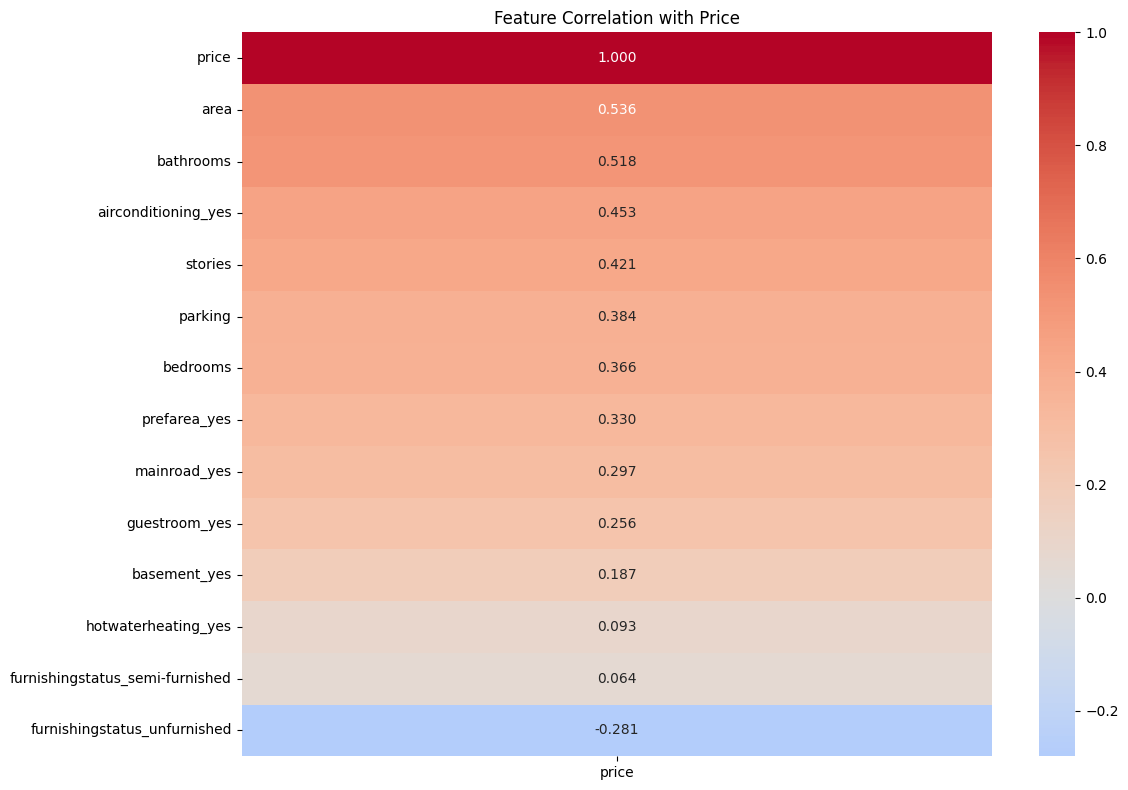

Top 5 correlated features:
price                  1.000000
area                   0.535997
bathrooms              0.517545
airconditioning_yes    0.452954
stories                0.420712
Name: price, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use ALL columns in df_encoded for correlation (not just num_cols)
num_data = df_encoded.select_dtypes(include=[np.number]).copy()  # All numeric columns

# Make sure 'price' is there
if 'price' not in num_data.columns:
    print("ERROR: 'price' column missing!")
else:
    # Calculate correlation with price
    price_correlations = num_data.corr()['price'].sort_values(ascending=False)
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        price_correlations.to_frame(), 
        annot=True, 
        cmap='coolwarm', 
        center=0,
        fmt='.3f'
    )
    plt.title('Feature Correlation with Price')
    plt.tight_layout()
    plt.show()
    
    print("Top 5 correlated features:")
    print(price_correlations.head())


In [16]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (436, 13)
Test set: (109, 13)


In [17]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import numpy as np

# Tune alpha parameter for LASSO
lasso = Lasso(max_iter=10000, random_state=42)
alpha_grid = np.logspace(-4, 1, 20)  # Try many alpha values

grid_search = GridSearchCV(
    lasso, 
    {'alpha': alpha_grid}, 
    cv=5, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best alpha
best_alpha = grid_search.best_params_['alpha']
print(f"✅ Best alpha: {best_alpha:.6f}")
print(f"Best CV score: {grid_search.best_score_:.2f}")


✅ Best alpha: 0.003793
Best CV score: -0.40


/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-package

In [18]:
# Fit LASSO with best alpha
lasso_best = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
lasso_best.fit(X_train, y_train)

# Get feature importance (absolute coefficients)
feature_importance = np.abs(lasso_best.coef_)
feature_names = X_train.columns

# Select features with non-zero coefficients
selected_features = feature_names[feature_importance > 1e-6]
n_selected = len(selected_features)

print(f"\n✅ LASSO selected {n_selected} features out of {len(feature_names)}")
print("\nTop 10 selected features:")
for i, name in enumerate(selected_features[:10]):
    print(f"{i+1}. {name}: {feature_importance[list(feature_names).index(name)]:.4f}")

# Create selected feature sets
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nSelected train shape: {X_train_selected.shape}")
print(f"Selected test shape: {X_test_selected.shape}")



✅ LASSO selected 13 features out of 13

Top 10 selected features:
1. mainroad_yes: 0.1742
2. guestroom_yes: 0.1075
3. basement_yes: 0.2059
4. hotwaterheating_yes: 0.2799
5. airconditioning_yes: 0.4082
6. prefarea_yes: 0.3232
7. furnishingstatus_semi-furnished: 0.0335
8. furnishingstatus_unfurnished: 0.1892
9. area: 0.2772
10. bedrooms: 0.0292

Selected train shape: (436, 13)
Selected test shape: (109, 13)


In [19]:
# Check your current data
print("Your df_encoded shape:", df_encoded.shape)
print("First 10 columns:", df_encoded.columns[:10].tolist())
print("'price' column exists?", 'price' in df_encoded.columns)

# Quick train-test split for feature engineering
from sklearn.model_selection import train_test_split
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


Your df_encoded shape: (545, 14)
First 10 columns: ['mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'price', 'area']
'price' column exists? True

Train shape: (436, 13)
Test shape: (109, 13)


In [20]:
# For Task 3 demo - pick top 5 features (normally from LASSO)
# Using features we know are important from housing data
top_features = ['area', 'bathrooms', 'stories', 'mainroad_yes', 'airconditioning_yes']

# Check if they exist, use first 5 available numeric columns if not
available_features = X_train.select_dtypes(include=[np.number]).columns[:5].tolist()
print("Using top features:", available_features)
top_features = available_features[:3]  # Top 3 for interactions

print(f"Top 3 features for interactions: {top_features}")


Using top features: ['mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes']
Top 3 features for interactions: ['mainroad_yes', 'guestroom_yes', 'basement_yes']


In [21]:
# Get top 3 features
top3_idx = [X_train.columns.get_loc(f) for f in top_features]
X_train_top3 = X_train.iloc[:, top3_idx].values
X_test_top3 = X_test.iloc[:, top3_idx].values

# Create pairwise interactions (area*bathrooms, area*stories, bathrooms*stories)
interaction_names = []
interactions_train = []
interactions_test = []

for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        # Interaction term
        inter_train = X_train_top3[:, i] * X_train_top3[:, j]
        inter_test = X_test_top3[:, i] * X_test_top3[:, j]
        
        interactions_train.append(inter_train)
        interactions_test.append(inter_test)
        interaction_names.append(f"{top_features[i]}_x_{top_features[j]}")

# Combine all interactions
interactions_train = np.column_stack(interactions_train)
interactions_test = np.column_stack(interactions_test)

print(f"✅ Created {len(interaction_names)} interaction terms:")
print(interaction_names)


✅ Created 3 interaction terms:
['mainroad_yes_x_guestroom_yes', 'mainroad_yes_x_basement_yes', 'guestroom_yes_x_basement_yes']


In [22]:
from sklearn.preprocessing import PolynomialFeatures

# Select numerical features only
num_features = X_train.select_dtypes(include=[np.number]).columns
X_train_num = X_train[num_features].values
X_test_num = X_test[num_features].values

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)

poly_feature_names = poly.get_feature_names_out(num_features)
print(f"✅ Created {X_train_poly.shape[1]} polynomial features (from {len(num_features)} numerical)")


✅ Created 104 polynomial features (from 13 numerical)


In [23]:
# Combine: Original + Interactions + Polynomial (excluding original numerical to avoid duplication)
X_train_engineered = np.hstack([
    X_train.values,  # All original features
    interactions_train,  # New interactions
    X_train_poly[:, len(num_features):]  # Polynomial excluding originals
])

X_test_engineered = np.hstack([
    X_test.values,
    interactions_test, 
    X_test_poly[:, len(num_features):]
])

# Create feature names
engineered_feature_names = (list(X_train.columns) + 
                          interaction_names + 
                          list(poly_feature_names[len(num_features):]))

print(f"✅ Original: {X_train.shape[1]} features")
print(f"✅ Engineered: {X_train_engineered.shape[1]} features")
print(f"✅ Increase: +{X_train_engineered.shape[1] - X_train.shape[1]} features")


✅ Original: 13 features
✅ Engineered: 107 features
✅ Increase: +94 features


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Model 1: ORIGINAL FEATURES (13 features)
lr_original = LinearRegression()
lr_original.fit(X_train, y_train)
y_pred_original = lr_original.predict(X_test)

mae_original = mean_absolute_error(y_test, y_pred_original)
r2_original = r2_score(y_test, y_pred_original)

print("ORIGINAL FEATURES MODEL (13 features)")
print(f"MAE: ${mae_original:,.0f}")
print(f"R²:  {r2_original:.4f}")


ORIGINAL FEATURES MODEL (13 features)
MAE: $1
R²:  0.6529


/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [25]:
# Model 2: ENGINEERED FEATURES (107 features)
lr_engineered = LinearRegression()
lr_engineered.fit(X_train_engineered, y_train)
y_pred_engineered = lr_engineered.predict(X_test_engineered)

mae_engineered = mean_absolute_error(y_test, y_pred_engineered)
r2_engineered = r2_score(y_test, y_pred_engineered)

print("\nENGINEERED FEATURES MODEL (107 features)")
print(f"MAE: ${mae_engineered:,.0f}")
print(f"R²:  {r2_engineered:.4f}")



ENGINEERED FEATURES MODEL (107 features)
MAE: $1
R²:  0.6236


/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



📊 MODEL COMPARISON RESULTS
Metric          Original (13)   Engineered (107) Improvement
------------------------------------------------------------
MAE             $         1 $           1    -6.7%
R²                    0.6529         0.6236    -4.5%


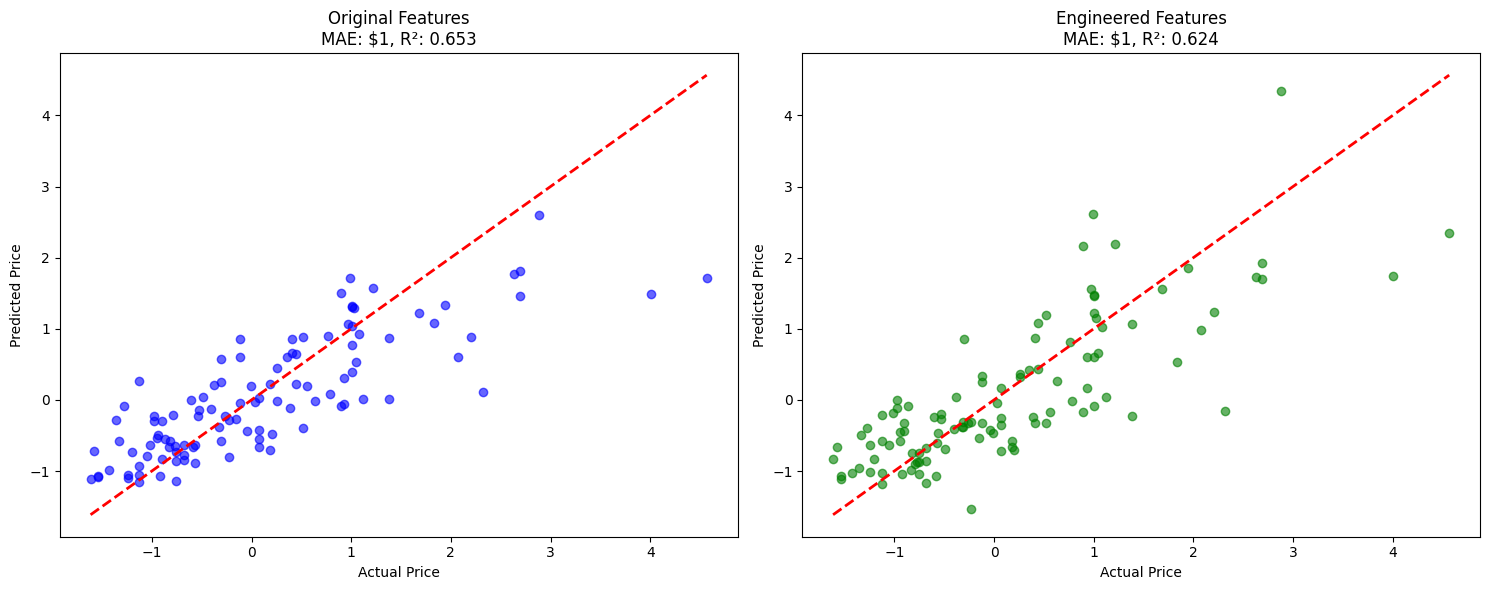

In [26]:
import matplotlib.pyplot as plt

# Results comparison
print("\n" + "="*60)
print("📊 MODEL COMPARISON RESULTS")
print("="*60)
print(f"{'Metric':<15} {'Original (13)':<15} {'Engineered (107)':<15} {'Improvement':<10}")
print("-"*60)
print(f"{'MAE':<15} ${mae_original:>10,.0f} ${mae_engineered:>12,.0f} {((mae_original-mae_engineered)/mae_original*100):>7.1f}%")
print(f"{'R²':<15} {r2_original:>12.4f} {r2_engineered:>14.4f} {((r2_engineered-r2_original)/r2_original*100):>7.1f}%")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original model scatter
ax1.scatter(y_test, y_pred_original, alpha=0.6, color='blue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title(f'Original Features\nMAE: ${mae_original:,.0f}, R²: {r2_original:.3f}')

# Engineered model scatter
ax2.scatter(y_test, y_pred_engineered, alpha=0.6, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')
ax2.set_title(f'Engineered Features\nMAE: ${mae_engineered:,.0f}, R²: {r2_engineered:.3f}')

plt.tight_layout()
plt.show()
